# Building Semantic Search: An Evaluation Benchmark

The earlier sections traced a progression from BM25 through LSI and word embeddings
to transformer bi-encoders and cross-encoders. Each step relaxed the independence
assumption between tokens and gained recall, but at a cost in compute, latency, and
precision. The book section "Building Semantic Search" (section 5, Pipelines A to E)
turns that progression into five concrete pipeline designs and a set of practical
recommendations. This notebook is the runnable companion: it builds all five pipelines
and measures them against each other on a realistic collection, so the tradeoffs become
numbers you can read rather than claims you have to trust.

This is an evaluation benchmark, so it rests on the machinery from Chapter 2
(Performance Evaluation): a query set, a pool of candidates, relevance judgments, and a
headline measure. Our headline measure is Mean Reciprocal Rank (MRR), chosen because
this collection is mostly a known-item task: most queries have a single correct movie,
and what matters is how high that one answer is ranked. We reuse Chapter 2's vocabulary
throughout and return, at the end, to its warnings about what these numbers can and
cannot tell us.

**What this notebook does:**

- Loads the `movies-small` collection (the first 500 movies from the Kaggle dataset)
- Documents how the benchmark was built: 14 queries, a pooled candidate set, and
  binary relevance judged once by an LLM judge
- Builds the five book pipelines (A to E) with their core logic inline
- Runs all 14 queries through nine pipeline conditions and reports MRR (the headline
  measure), live latency, and storage
- Shows the Matryoshka truncation sweep (recall versus storage) behind Pipeline E
- Zooms into the queries where the pipelines disagree, with named examples

**Prerequisites:** ch05-04 (bi-encoders and cross-encoders), ch01 (BM25), and Chapter 2
(evaluation measures).

## Setup

We load the dense models through `sentence-transformers`. We silence informational
logging so the output stays readable.

<div style="border-left: 4px solid #64748B; background: rgba(100, 116, 139, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#64748B; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">First run downloads the models</strong><br>
The first run downloads the three models from Hugging Face and caches them locally (roughly 1.4 GB in total): all-MiniLM-L6-v2 (about 90 MB), Qwen3-Embedding-0.6B (about 1.2 GB), and cross-encoder/ms-marco-MiniLM-L-6-v2 (about 90 MB). Later runs load them from the cache in seconds.
</div>

In [1]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer, CrossEncoder

from shared.display import print_table, display_md
from shared.collections import load_collection
from shared.text import tokenize, remove_stopwords
from shared.retrieval import document_frequencies, rank_collection_bm25

import warnings
warnings.filterwarnings("ignore")
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

EVAL_DIR = Path("eval/ch05_movies")
EMB_DIR = EVAL_DIR / "embeddings"

We load `movies-small` and index it by id. Each movie's searchable text combines its
title, overview, tagline, top cast, and genres. These 500 films span the years 1964 to
1997, so the collection is a self-contained slice we can reason about by hand.

In [2]:
collection = load_collection("movies-small")
docs = collection.documents()
id_to_doc = {d["id"]: d for d in docs}
id_to_text = {d["id"]: d["text"] for d in docs}
id_to_title = {d["id"]: d["title"] for d in docs}

display_md(
    f"**Collection:** `{collection.name}`, {len(docs)} movies\n\n"
    f"| Property | Value |\n"
    f"|----------|-------|\n"
    f"| Documents | {len(docs)} |\n"
    f"| Year range | {min(d['year'] for d in docs)} to {max(d['year'] for d in docs)} |\n"
    f"| Mean length | {np.mean([len(d['text'].split()) for d in docs]):.0f} whitespace tokens |\n"
    f"| Text fields | title, overview, tagline, cast, genres |"
)

**Collection:** `movies-small`, 500 movies

| Property | Value |
|----------|-------|
| Documents | 500 |
| Year range | 1964 to 1997 |
| Mean length | 96 whitespace tokens |
| Text fields | title, overview, tagline, cast, genres |

Here is one movie in full, so the retrieval units are concrete before we search them.

In [3]:
sample = id_to_doc["tt0114709"]  # Toy Story (1995)
display_md(
    f"**Sample movie:** {sample['title']} ({sample['year']})\n\n"
    f"- **Genres:** {', '.join(sample['genres'])}\n"
    f"- **Rating:** {sample['rating']}  |  **Runtime:** {sample['runtime']} min\n\n"
    f"**Searchable text:**\n\n> {sample['text']}"
)

**Sample movie:** Toy Story (1995)

- **Genres:** Animation, Comedy, Family
- **Rating:** 7.7  |  **Runtime:** 81 min

**Searchable text:**

> Toy Story Led by Woody, Andy's toys live happily in his room until Andy's birthday brings Buzz Lightyear onto the scene. Afraid of losing his place in Andy's heart, Woody plots against Buzz. But when circumstances separate Buzz and Woody from their owner, the duo eventually learns to put aside their differences. Tom Hanks as Woody (voice), Tim Allen as Buzz Lightyear (voice), Don Rickles as Mr. Potato Head (voice), Jim Varney as Slinky Dog (voice), Wallace Shawn as Rex (voice), John Ratzenberger as Hamm (voice), Laurie Metcalf as Mrs. Davis (voice), R. Lee Ermey as Sergeant (voice), Penn Jillette as TV Announcer (voice) Animation Comedy Family

## The Evaluation Setup

A benchmark is only as trustworthy as the ground truth behind it. Before we run any
pipeline, we document exactly how this one was built, following the four components
from Chapter 2: a collection, an information need expressed as queries, a judging pool,
and relevance judgments.

**How the queries were chosen.** The 14 queries are not random. Each one deliberately
probes an aspect where the pipelines and the two embedding models should behave
differently. The probe types are:

- `exact-title`: a bare title such as "GoldenEye", where BM25 should match the literal
  tokens and dense retrieval has almost no plot context to work with.
- `exact-cast-name`: an actor name such as "Samuel L. Jackson", a proper noun that BM25
  matches directly but dense models struggle to localise.
- `genre-plot-semantic`: a theme such as "animated film about toys that come to life",
  where meaning matters more than shared words.
- `paraphrase-noshare`: a plot description written to share almost no vocabulary with
  the target's overview, such as the Se7en or Braveheart paraphrases, where dense
  retrieval should win decisively and BM25 should fail.
- `open-semantic`: a broad archetype (q13, spy thriller) with no single correct answer.

**How candidates were pooled.** We ran every pipeline condition over every query and
collected the union of their top-10 results. This is the pooling method from Chapter 2:
we judge only the documents that at least one system retrieved, and treat everything
unjudged as not relevant. The pool holds the (query, movie) pairs any pipeline surfaced.

**How relevance was judged.** Each pooled pair was judged once by a Claude LLM judge
with binary relevance (1 = the movie genuinely satisfies the query, 0 = it does not),
applying the rule that topical adjacency or a shared keyword alone is not enough. The
result is shipped as `qrels.json`.

<div style="border-left: 4px solid #64748B; background: rgba(100, 116, 139, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#64748B; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Reproducible versus pre-shipped</strong><br>
The full offline harness is reproducible: <a href="demos/eval/ch05_movies/run_trial.py"><code>demos/eval/ch05_movies/run_trial.py</code></a> rebuilds every ranked list, the pool, the cost tables, and the Matryoshka sweep. Three things are pre-shipped and loaded here rather than recomputed, for good reasons. The <strong>corpus embeddings</strong> (<a href="demos/eval/ch05_movies/embeddings/"><code>embeddings/*.npy</code></a>): encoding all 500 movies with the large Qwen model takes about 12 minutes on CPU, so we ship the normalised matrices and load them in a fraction of a second. The <strong>query set</strong> (<a href="demos/eval/ch05_movies/queries.json"><code>queries.json</code></a>) was hand-designed. The <strong>judgments</strong> (<a href="demos/eval/ch05_movies/qrels.json"><code>qrels.json</code></a>) were produced once by the LLM judge offline. We still build the BM25 index live and encode every query live, so the retrieval and the timing you see are real.
</div>

<div style="border-left: 4px solid #D97706; background: rgba(217, 119, 6, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#D97706; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">What a benchmark this size can and cannot tell you</strong><br>
Chapter 2's section "When Evaluation Misleads" applies directly here, and we read these numbers in its light. Relevance is <strong>subjective</strong>: our judge drew borderline calls (is a live-action film with toys that come alive an "animated film about toys"?) that another judge would draw differently. Judges <strong>disagree</strong>, which puts a floor under how small a score gap is meaningful. The pool is <strong>incomplete</strong>: a relevant movie that no pipeline retrieved was never judged and silently counts as not relevant, which biases recall. And the query set is <strong>tiny</strong> (14 queries), so a single query swings every average. Read the table that follows as a <strong>comparative</strong> instrument that shows how the pipelines differ in character, not as an absolute measurement of their quality.
</div>

We load the query set and the judgments and show a sample of each.

In [4]:
queries = json.loads((EVAL_DIR / "queries.json").read_text(encoding="utf-8"))["queries"]
qrels = json.loads((EVAL_DIR / "qrels.json").read_text(encoding="utf-8"))
qrels = {qid: labels for qid, labels in qrels.items() if qid.startswith("q")}

# Relevant set per query: the pooled movies judged 1.
relevant = {qid: {mid for mid, lbl in qrels[qid].items() if lbl == 1} for qid in qrels}

rows = [[q["id"], q["probe"] + (" (open)" if q.get("open") else ""),
         q["text"][:60], len(relevant[q["id"]])]
        for q in queries]
display_md("**The 14 queries, their probe types, and how many pooled movies were judged relevant:**")
print_table(rows, headers=["ID", "Probe", "Query", "# relevant"])

**The 14 queries, their probe types, and how many pooled movies were judged relevant:**

| ID   | Probe                 | Query                                                        |   # relevant |
|:-----|:----------------------|:-------------------------------------------------------------|-------------:|
| q01  | exact-title           | GoldenEye                                                    |            1 |
| q02  | exact-title           | Twelve Monkeys                                               |            1 |
| q03  | exact-title-ambiguous | Heat                                                         |            1 |
| q04  | exact-cast-name       | Samuel L. Jackson                                            |            9 |
| q05  | cast-name-nl          | movies starring Robin Williams                               |            5 |
| q06  | mixed-cast-plot       | Robert De Niro as a Las Vegas casino boss                    |            1 |
| q07  | genre-plot-semantic   | animated film about toys that come to life                   |            1 |
| q08  | genre-plot-semantic   | a dark thriller about a detective hunting a serial killer    |            3 |
| q09  | paraphrase-noshare    | two investigators track a methodical murderer punishing peop |            1 |
| q10  | paraphrase-noshare    | a prisoner is sent to the past to trace a plague that almost |            1 |
| q11  | paraphrase-noshare    | a self-destructive man bent on ending his life bonds with a  |            1 |
| q12  | paraphrase-noshare    | a medieval highland warrior rallies his people to overthrow  |            1 |
| q13  | open-semantic (open)  | secret agent spy thriller with gadgets and a villain plottin |            4 |
| q14  | paraphrase-plot       | a lighthearted comedy about a failed athlete who becomes an  |            1 |

Most queries have a single relevant movie (one correct title to recover). A few have
several: the actor-name queries q04 and q05, the serial-killer theme q08, and the open
spy query q13. This distribution is exactly why we report MRR as the headline measure.

Chapter 2 makes the point that the measure has to fit the task, and this task is mostly
known-item retrieval: one query, one correct answer. For a single-relevant query,
Precision@k is bounded by (number of relevant) / k, so P@5 can be at most 0.20 and P@10
at most 0.10 no matter how good the ranking is. Precision@k then mostly just reports
whether the one answer landed somewhere in the top k, not how high. MRR, the mean of
1 / (rank of the first relevant result), measures the rank of the one correct movie
directly, which is precisely what matters when there is a single answer to find. The
few multi-relevant queries (the two cast queries and the open spy query) could also be
read with P@k, but for simplicity, and because the collection is overwhelmingly
known-item, we report a single headline measure.

<div style="border-left: 4px solid #2563EB; background: rgba(37, 99, 235, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#2563EB; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Why MRR is the right headline measure here</strong><br>
This is Chapter 2's rule in action: choose the measure that fits the task. The task is mostly known-item retrieval (one correct movie per query), so Precision@k is capped by the handful of relevant documents and barely moves. MRR scores how high the one correct answer sits, which is the question a single-answer search actually asks. We therefore lead with MRR and drop the P@k columns from the main table rather than report measures the task structure flattens.
</div>

In [5]:
# One judged pool, shown for q09 (the Se7en paraphrase): the movies some pipeline
# surfaced, and the single one the judge marked relevant.
q09_pool = qrels["q09"]
rel_ids = {mid for mid, lbl in q09_pool.items() if lbl == 1}
rows = [[id_to_title.get(mid, "?"), id_to_doc.get(mid, {}).get("year", "?"), "yes" if lbl else "no"]
        for mid, lbl in list(q09_pool.items())[:12]]
display_md(
    "**Judging pool sample for q09** *(two investigators track a methodical murderer "
    "punishing people for the cardinal vices)*:\n\n"
    f"{len(q09_pool)} movies pooled, {len(rel_ids)} judged relevant."
)
print_table(rows, headers=["Movie (pooled)", "Year", "Relevant?"])

**Judging pool sample for q09** *(two investigators track a methodical murderer punishing people for the cardinal vices)*:

34 movies pooled, 1 judged relevant.

| Movie (pooled)                                   |   Year | Relevant?   |
|:-------------------------------------------------|-------:|:------------|
| Bad Boys                                         |   1995 | no          |
| Batman Forever                                   |   1995 | no          |
| Before and After                                 |   1996 | no          |
| Beverly Hills Cop III                            |   1994 | no          |
| Brother Minister: The Assassination of Malcolm X |   1995 | no          |
| Clockers                                         |   1995 | no          |
| Copycat                                          |   1995 | no          |
| Demolition Man                                   |   1993 | no          |
| Dos Crímenes                                     |   1995 | no          |
| Drop Zone                                        |   1994 | no          |
| Fall Time                                        |   1995 | no          |
| Guilty as Sin                                    |   1993 | no          |

## The Five Pipelines (A to E)

We now build each pipeline. The core retrieval logic is written inline here, because
seeing it is the lesson; only the BM25 plumbing comes from `shared.retrieval`. Every
pipeline is demonstrated on one query chosen to make its behaviour visible before we run
the full benchmark. All dense retrieval uses cosine similarity on L2-normalised
embeddings, so a dot product equals cosine (the measure the book uses throughout).

First we load the two embedding models and the cross-encoder, and the pre-shipped
corpus embeddings. The large Qwen model takes the longest to load (roughly a minute and
a half on CPU, a one-time cost); encoding a single query with it afterwards is fast
(about a third of a second).

In [6]:
t0 = time.time()
model_small = SentenceTransformer("all-MiniLM-L6-v2")
t_small_load = time.time() - t0

t0 = time.time()
model_large = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
t_large_load = time.time() - t0

t0 = time.time()
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")
t_ce_load = time.time() - t0

display_md(
    "**Models loaded (one-time cost):**\n\n"
    f"| Model | Role | Load time |\n"
    f"|-------|------|-----------|\n"
    f"| all-MiniLM-L6-v2 (384d) | small bi-encoder | {t_small_load:.1f} s |\n"
    f"| Qwen3-Embedding-0.6B (1024d) | large bi-encoder | {t_large_load:.1f} s |\n"
    f"| ms-marco-MiniLM-L-6-v2 | cross-encoder reranker | {t_ce_load:.1f} s |"
)

**Models loaded (one-time cost):**

| Model | Role | Load time |
|-------|------|-----------|
| all-MiniLM-L6-v2 (384d) | small bi-encoder | 2.3 s |
| Qwen3-Embedding-0.6B (1024d) | large bi-encoder | 3.6 s |
| ms-marco-MiniLM-L-6-v2 | cross-encoder reranker | 2.4 s |

The corpus embeddings are loaded from disk in the manifest's document order, so row `i`
corresponds to `doc_ids[i]`. We never re-encode the corpus here.

In [7]:
manifest = json.loads((EMB_DIR / "manifest.json").read_text(encoding="utf-8"))
doc_ids = manifest["doc_id_order"]

emb_small = np.load(EMB_DIR / "minilm_movies_small.npy")   # (500, 384)
emb_large = np.load(EMB_DIR / "qwen_movies_small.npy")     # (500, 1024)

display_md(
    "**Pre-shipped corpus embeddings loaded (no re-encoding):**\n\n"
    f"| Matrix | Shape | Bytes/doc | Total |\n"
    f"|--------|-------|-----------|-------|\n"
    f"| MiniLM | {emb_small.shape} | {emb_small.shape[1]*4} | {emb_small.nbytes/1e6:.3f} MB |\n"
    f"| Qwen | {emb_large.shape} | {emb_large.shape[1]*4} | {emb_large.nbytes/1e6:.3f} MB |"
)

**Pre-shipped corpus embeddings loaded (no re-encoding):**

| Matrix | Shape | Bytes/doc | Total |
|--------|-------|-----------|-------|
| MiniLM | (500, 384) | 1536 | 0.768 MB |
| Qwen | (500, 1024) | 4096 | 2.048 MB |

A small helper renders a ranked list with movie titles so the demos are readable.

In [8]:
def show_ranking(ranked, title, note=None, k=5):
    """Render a (doc_id, score) ranking as a titled table."""
    rows = []
    for rank, (doc_id, score) in enumerate(ranked[:k], start=1):
        doc = id_to_doc.get(doc_id, {})
        rows.append([rank, f"{doc.get('title', '?')} ({doc.get('year', '?')})", f"{score:.3f}"])
    if note:
        display_md(note)
    display_md(f"**{title}**")
    print_table(rows, headers=["Rank", "Movie", "Score"])

### Pipeline A: BM25 only

Pipeline A is the classical baseline: an inverted index with BM25 scoring, no semantic
component. We build the index live from the tokenised, stopword-filtered movie texts.
BM25 excels when the query and the documents share surface vocabulary, especially exact
titles and proper nouns.

In [9]:
# Build the BM25 index live (one-time cost, timed later in the benchmark).
corpus = {d["id"]: remove_stopwords(tokenize(d["text"])) for d in docs}
df = document_frequencies(corpus)

def bm25_search(query, top_k=10):
    """Pipeline A: rank by BM25, keep positive scores only."""
    q_tokens = remove_stopwords(tokenize(query))
    ranked = rank_collection_bm25(q_tokens, corpus, df)
    return [(doc_id, score) for doc_id, score in ranked if score > 0][:top_k]

We demonstrate on q04, the actor name "Samuel L. Jackson". BM25 matches the name tokens
directly, so the top results are his films (he appears in roughly nine of the 500
movies). This is the case where exact matching is exactly what you want.

In [10]:
show_ranking(bm25_search("Samuel L. Jackson"),
             "Pipeline A (BM25) for q04: Samuel L. Jackson",
             note="BM25 keys on the literal name tokens, so it surfaces his filmography.")

BM25 keys on the literal name tokens, so it surfaces his filmography.

**Pipeline A (BM25) for q04: Samuel L. Jackson**

|   Rank | Movie                    |   Score |
|-------:|:-------------------------|--------:|
|      1 | Menace II Society (1993) |  10.976 |
|      2 | Fresh (1994)             |   9.445 |
|      3 | Fluke (1995)             |   9.386 |
|      4 | Losing Isaiah (1995)     |   9.155 |
|      5 | The New Age (1994)       |   9.155 |

### Pipeline B: BM25 then cross-encoder rerank

Pipeline B keeps the BM25 first stage but reorders its candidates with a cross-encoder.
The cross-encoder reads the query and each candidate document jointly and scores their
relevance; it is the most precise and most expensive stage, so it only ever runs on a
short candidate list produced by a cheaper first stage.

In [11]:
def cross_encoder_rerank(query, candidate_ids, top_k=10):
    """Rerank candidates by joint (query, document) relevance."""
    if not candidate_ids:
        return []
    pairs = [[query, id_to_text[cid]] for cid in candidate_ids]
    scores = cross_encoder.predict(pairs, show_progress_bar=False)
    ranked = sorted(zip(candidate_ids, scores), key=lambda x: -float(x[1]))
    return [(cid, float(s)) for cid, s in ranked[:top_k]]

def bm25_cross_encoder(query, retrieve_k=50, top_k=10):
    """Pipeline B: BM25 retrieves a pool, the cross-encoder reorders it."""
    candidates = [doc_id for doc_id, _ in bm25_search(query, top_k=retrieve_k)]
    return cross_encoder_rerank(query, candidates, top_k=top_k)

We demonstrate on q03, the ambiguous common-word title "Heat". BM25 alone is swamped
because the word "heat" appears in many overviews, so the 1995 crime film is not at the
top. The cross-encoder, reading the query against each candidate, pulls the right film
up.

In [12]:
show_ranking(bm25_search("Heat"),
             "Pipeline A (BM25 only) for q03: Heat",
             note="The common word *heat* appears in many overviews, so BM25 alone is noisy.")
show_ranking(bm25_cross_encoder("Heat"),
             "Pipeline B (BM25 then cross-encoder) for q03: Heat",
             note="The cross-encoder reorders the same candidates by true relevance.")

The common word *heat* appears in many overviews, so BM25 alone is noisy.

**Pipeline A (BM25 only) for q03: Heat**

|   Rank | Movie                 |   Score |
|-------:|:----------------------|--------:|
|      1 | Color of Night (1994) |   4.96  |
|      2 | Heat (1995)           |   3.562 |

The cross-encoder reorders the same candidates by true relevance.

**Pipeline B (BM25 then cross-encoder) for q03: Heat**

|   Rank | Movie                 |   Score |
|-------:|:----------------------|--------:|
|      1 | Heat (1995)           |  -2.475 |
|      2 | Color of Night (1994) |  -3.384 |

### Pipeline C: dense bi-encoder retrieval

Pipeline C replaces BM25 with a bi-encoder that retrieves by semantic similarity. We
compare a small model (MiniLM, 384d) and a larger one (Qwen, 1024d). The query is
encoded live; the MiniLM query is encoded raw, while the Qwen model expects an
instruction prefix, which we select with its `"query"` prompt.

In [13]:
def dense_search(query, model, doc_embeddings, prompt_name=None, top_k=10):
    """Pipeline C: top-k by cosine on normalised embeddings."""
    kwargs = {"normalize_embeddings": True, "show_progress_bar": False}
    if prompt_name is not None:
        kwargs["prompt_name"] = prompt_name
    q_emb = np.asarray(model.encode([query], **kwargs)[0], dtype=np.float32)
    sims = doc_embeddings @ q_emb
    idx = np.argsort(-sims)[:top_k]
    return [(doc_ids[i], float(sims[i])) for i in idx]

We demonstrate on q09, a paraphrase of the Se7en plot written to share almost no words
with its overview ("investigators" not detectives, "cardinal vices" not seven deadly
sins). BM25 cannot bridge this vocabulary gap. The small dense model gets close but
misses; the large model recovers Se7en at the top. This is the paraphrase case where
model capacity pays off.

In [14]:
q09_text = "two investigators track a methodical murderer punishing people for the cardinal vices"
show_ranking(dense_search(q09_text, model_small, emb_small),
             "Pipeline C (small, MiniLM) for q09",
             note="A paraphrase with no shared vocabulary. The small model groups the theme loosely.")
show_ranking(dense_search(q09_text, model_large, emb_large, prompt_name="query"),
             "Pipeline C (large, Qwen) for q09",
             note="The larger model recovers the target film from meaning alone.")

A paraphrase with no shared vocabulary. The small model groups the theme loosely.

**Pipeline C (small, MiniLM) for q09**

|   Rank | Movie                     |   Score |
|-------:|:--------------------------|--------:|
|      1 | Guilty as Sin (1993)      |   0.495 |
|      2 | Judge Dredd (1995)        |   0.379 |
|      3 | The Usual Suspects (1995) |   0.356 |
|      4 | Copycat (1995)            |   0.349 |
|      5 | Bad Boys (1995)           |   0.345 |

The larger model recovers the target film from meaning alone.

**Pipeline C (large, Qwen) for q09**

|   Rank | Movie                      |   Score |
|-------:|:---------------------------|--------:|
|      1 | Se7en (1995)               |   0.539 |
|      2 | Kalifornia (1993)          |   0.487 |
|      3 | Guilty as Sin (1993)       |   0.481 |
|      4 | Murder in the First (1995) |   0.477 |
|      5 | Jade (1995)                |   0.474 |

### Pipeline D: hybrid BM25 plus dense with Reciprocal Rank Fusion

Pipeline D runs BM25 and dense retrieval in parallel and fuses their ranked lists with
Reciprocal Rank Fusion (RRF). RRF uses only the rank of each document in each list, not
its raw score, so the two incomparable score scales never need calibration. For a
document $d$ across result lists $R$:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

where $k$ (the book uses 60) dampens the influence of the very top ranks. A document
both retrievers rank highly collects contributions from both and rises. An optional
cross-encoder can rerank the fused pool as a final precision stage.

In [15]:
def reciprocal_rank_fusion(ranked_lists, k=60):
    """Merge ranked lists using ranks only."""
    scores = {}
    for ranked_list in ranked_lists:
        for rank, (doc_id, _) in enumerate(ranked_list, start=1):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank)
    return sorted(scores.items(), key=lambda x: -x[1])

def hybrid_rrf(query, model, doc_embeddings, prompt_name=None,
               retrieve_k=50, k_rrf=60, rerank=False, top_k=10):
    """Pipeline D: fuse BM25 and dense, optionally rerank with the cross-encoder."""
    bm = bm25_search(query, top_k=retrieve_k)
    de = dense_search(query, model, doc_embeddings, prompt_name, top_k=retrieve_k)
    fused = reciprocal_rank_fusion([bm, de], k=k_rrf)
    if rerank:
        candidates = [doc_id for doc_id, _ in fused[:retrieve_k]]
        return cross_encoder_rerank(query, candidates, top_k=top_k)
    return fused[:top_k]

We demonstrate on q08, "a dark thriller about a detective hunting a serial killer",
showing the BM25 list, the dense list, and the fused list side by side so the mechanism
is visible. BM25 and the dense model surface different candidates; RRF boosts the ones
they agree on.

In [16]:
q08_text = "a dark thriller about a detective hunting a serial killer"
bm_list = bm25_search(q08_text, top_k=10)
de_list = dense_search(q08_text, model_large, emb_large, prompt_name="query", top_k=10)
fused = reciprocal_rank_fusion([bm_list, de_list], k=60)

rows = []
for rank in range(5):
    bm_e = f"{id_to_title.get(bm_list[rank][0], '-')}" if rank < len(bm_list) else "-"
    de_e = f"{id_to_title.get(de_list[rank][0], '-')}" if rank < len(de_list) else "-"
    fu_e = f"{id_to_title.get(fused[rank][0], '-')}" if rank < len(fused) else "-"
    rows.append([rank + 1, bm_e, de_e, fu_e])
display_md(f"**Pipeline D for q08** *(dark thriller, detective hunting a serial killer)*")
print_table(rows, headers=["Rank", "BM25", "Dense (Qwen)", "Fused (RRF)"])

**Pipeline D for q08** *(dark thriller, detective hunting a serial killer)*

|   Rank | BM25         | Dense (Qwen)   | Fused (RRF)   |
|-------:|:-------------|:---------------|:--------------|
|      1 | Se7en        | Kalifornia     | Se7en         |
|      2 | Copycat      | Se7en          | Kalifornia    |
|      3 | Kalifornia   | Heat           | Copycat       |
|      4 | Hideaway     | The Fugitive   | The Fugitive  |
|      5 | The Fugitive | Clockers       | Heat          |

### Pipeline E: multi-stage retrieval with Matryoshka truncation

Pipeline E targets scale. As a collection grows past a million documents, storing and
scanning every full-precision vector dominates the cost. Pipeline E uses a cheap first
stage to scan the whole collection, then a precise full-dimension stage to rerank the
survivors. One way to build the cheap stage is Matryoshka Representation Learning: the
Qwen model is trained so that a truncated prefix of its embedding is still usable. We
scan with the first 256 dimensions, then rerank the top candidates with the full 1024
dimensions. No second model and no re-encoding are needed.

In [17]:
def truncate_normalize(embeddings, dim):
    """Keep the first `dim` components of each row and renormalise."""
    sub = embeddings[:, :dim]
    norms = np.linalg.norm(sub, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return (sub / norms).astype(np.float32)

def multistage_matryoshka(query, first_dim=256, first_k=50, rerank=False, top_k=10):
    """Pipeline E: truncated first stage over all docs, then full-dim rerank."""
    q_full = np.asarray(
        model_large.encode([query], prompt_name="query",
                            normalize_embeddings=True, show_progress_bar=False)[0],
        dtype=np.float32)
    # Stage 1: cheap scan with the truncated prefix.
    q1 = q_full[:first_dim]
    q1 = q1 / (np.linalg.norm(q1) or 1.0)
    sims1 = truncate_normalize(emb_large, first_dim) @ q1
    cand_idx = np.argsort(-sims1)[:first_k]
    # Stage 2: precise full-dimension rerank of the survivors.
    sims2 = emb_large[cand_idx] @ q_full
    order = np.argsort(-sims2)
    reranked = [(doc_ids[cand_idx[i]], float(sims2[i])) for i in order]
    if rerank:
        candidates = [doc_id for doc_id, _ in reranked[:first_k]]
        return cross_encoder_rerank(query, candidates, top_k=top_k)
    return reranked[:top_k]

We demonstrate on q12, a paraphrase of Braveheart ("a medieval highland warrior rallies
his people to overthrow their foreign rulers", avoiding Scottish, English, and revolt).
The 256-dimension first stage is enough to keep Braveheart in the candidate pool, and
the full-dimension rerank lifts it to the top: the same answer as full dense retrieval,
reached through a cheaper scan.

In [18]:
q12_text = "a medieval highland warrior rallies his people to overthrow their foreign rulers"
show_ranking(multistage_matryoshka(q12_text),
             "Pipeline E (Matryoshka 256d then full-dim rerank) for q12",
             note="A cheap 256d scan keeps the target in the pool; the full-dim rerank finishes the job.")

A cheap 256d scan keeps the target in the pool; the full-dim rerank finishes the job.

**Pipeline E (Matryoshka 256d then full-dim rerank) for q12**

|   Rank | Movie                                  |   Score |
|-------:|:---------------------------------------|--------:|
|      1 | Braveheart (1995)                      |   0.528 |
|      2 | Target (1995)                          |   0.487 |
|      3 | Queen Margot (1994)                    |   0.448 |
|      4 | Highlander: The Final Dimension (1994) |   0.433 |
|      5 | A Kid in King Arthur's Court (1995)    |   0.389 |

## Running the Benchmark

We now run all 14 queries through nine conditions and score each ranking against the
judgments. The conditions are the five pipelines, split by model and reranker where it
matters: A (BM25), B (BM25 plus cross-encoder), C-small and C-large (dense), D-small and
D-large (hybrid RRF), D-large plus cross-encoder, E-large (Matryoshka), and E-large plus
cross-encoder.

The headline measure is implemented inline, tying back to its Chapter 2 definition. The
reciprocal rank is one over the position of the first relevant result (zero if none
appears); MRR is its mean over the query set.

In [19]:
def reciprocal_rank(ranked_ids, rel):
    """1 / rank of the first relevant result, else 0."""
    for i, d in enumerate(ranked_ids, start=1):
        if d in rel:
            return 1.0 / i
    return 0.0

We time the BM25 index build and each per-query retrieval call live.

In [20]:
# Time the one-time BM25 index build (rebuild it so the timing is honest).
t0 = time.time()
_corpus = {d["id"]: remove_stopwords(tokenize(d["text"])) for d in docs}
_df = document_frequencies(_corpus)
bm25_build_s = time.time() - t0

conditions = {
    "A-bm25":                    lambda q: bm25_search(q, top_k=10),
    "B-bm25+crossenc":           lambda q: bm25_cross_encoder(q, top_k=10),
    "C-dense-small":             lambda q: dense_search(q, model_small, emb_small, top_k=10),
    "C-dense-large":             lambda q: dense_search(q, model_large, emb_large, "query", top_k=10),
    "D-hybrid-small":            lambda q: hybrid_rrf(q, model_small, emb_small, top_k=10),
    "D-hybrid-large":            lambda q: hybrid_rrf(q, model_large, emb_large, "query", top_k=10),
    "D-hybrid-large+crossenc":   lambda q: hybrid_rrf(q, model_large, emb_large, "query", rerank=True, top_k=10),
    "E-matryoshka-large":        lambda q: multistage_matryoshka(q, top_k=10),
    "E-matryoshka-large+crossenc": lambda q: multistage_matryoshka(q, rerank=True, top_k=10),
}

results = {name: {} for name in conditions}   # name -> {qid: [doc_id, ...]}
latency = {name: [] for name in conditions}

for q in queries:
    for name, fn in conditions.items():
        t0 = time.time()
        ranked = fn(q["text"])
        latency[name].append(time.time() - t0)
        results[name][q["id"]] = [doc_id for doc_id, _ in ranked]

display_md(f"Ran {len(conditions)} conditions over {len(queries)} queries. "
           f"BM25 index build: {bm25_build_s*1000:.0f} ms.")

Ran 9 conditions over 14 queries. BM25 index build: 20 ms.

Now we aggregate MRR over the 14 queries, and attach the live mean
latency and the storage each condition needs. Storage is the dense vector footprint:
BM25 keeps a sparse inverted index (not dense vectors); the small-model conditions store
the 384d matrix; the large-model conditions store the full 1024d matrix.

In [21]:
storage_label = {
    "A-bm25": "sparse index",
    "B-bm25+crossenc": "sparse index",
    "C-dense-small": f"{emb_small.nbytes/1e6:.2f} MB (384d)",
    "C-dense-large": f"{emb_large.nbytes/1e6:.2f} MB (1024d)",
    "D-hybrid-small": f"{emb_small.nbytes/1e6:.2f} MB (384d)",
    "D-hybrid-large": f"{emb_large.nbytes/1e6:.2f} MB (1024d)",
    "D-hybrid-large+crossenc": f"{emb_large.nbytes/1e6:.2f} MB (1024d)",
    "E-matryoshka-large": f"{emb_large.nbytes/1e6:.2f} MB (1024d)",
    "E-matryoshka-large+crossenc": f"{emb_large.nbytes/1e6:.2f} MB (1024d)",
}

rows = []
for name in conditions:
    mrr = np.mean([reciprocal_rank(results[name][qid], relevant[qid]) for qid in results[name]])
    ms = 1000.0 * np.mean(latency[name])
    rows.append([name, f"{mrr:.3f}", f"{ms:.0f}", storage_label[name]])

display_md("**Benchmark results: 14 queries, nine conditions. MRR is the headline measure.**")
print_table(rows, headers=["Condition", "MRR", "Latency (ms)", "Storage"])

**Benchmark results: 14 queries, nine conditions. MRR is the headline measure.**

| Condition                   |   MRR |   Latency (ms) | Storage         |
|:----------------------------|------:|---------------:|:----------------|
| A-bm25                      | 0.579 |              3 | sparse index    |
| B-bm25+crossenc             | 0.774 |            298 | sparse index    |
| C-dense-small               | 0.615 |              6 | 0.77 MB (384d)  |
| C-dense-large               | 0.774 |            223 | 2.05 MB (1024d) |
| D-hybrid-small              | 0.693 |             10 | 0.77 MB (384d)  |
| D-hybrid-large              | 0.702 |            225 | 2.05 MB (1024d) |
| D-hybrid-large+crossenc     | 0.81  |            603 | 2.05 MB (1024d) |
| E-matryoshka-large          | 0.774 |            222 | 2.05 MB (1024d) |
| E-matryoshka-large+crossenc | 0.774 |            617 | 2.05 MB (1024d) |

<div style="border-left: 4px solid #D97706; background: rgba(217, 119, 6, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#D97706; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Read the ordering, not the absolute latency</strong><br>
The latency column is measured live on this machine's CPU, so the absolute milliseconds depend entirely on the hardware and will differ on yours. What transfers is the <strong>relative ordering</strong>: BM25 is the cheapest by far, dense retrieval with the small model is next, the large model costs more per query because it encodes the query through a far bigger network, and any condition with a cross-encoder is the most expensive because it runs a full transformer pass per candidate. These ratios match the cost model in the book.
</div>

Reading the table against Chapter 2's caution: MRR reads directly as how high each
condition places the one correct movie, which is the question this mostly known-item
task asks. The large-model conditions and the cross-encoder conditions reach the highest
MRR, so they put the right answer nearer the top more often. The gaps between
neighbouring conditions are small, and with only 14 queries a single query moves every
average, so we treat these as indications of character rather than verdicts.

## Efficiency Exhibit: the Matryoshka Sweep (Pipeline E)

Pipeline E rests on a claim: a truncated prefix of the Qwen embedding is still a usable
embedding, so a low-dimension first stage can filter the collection cheaply. The sweep
below quantifies the tradeoff. For each truncation dimension, it measures recall@10
against the full-dimension top-10 (how many of the full-precision top-10 the truncated
ranking still finds) and the storage that dimension needs. The sweep is pre-computed in
<a href="demos/eval/ch05_movies/matryoshka_sweep.json"><code>demos/eval/ch05_movies/matryoshka_sweep.json</code></a>
and reproducible from the Qwen embeddings via the harness.

In [22]:
sweep = json.loads((EVAL_DIR / "matryoshka_sweep.json").read_text(encoding="utf-8"))
per_dim = sweep["per_dim"]
dims_sorted = sorted((int(d) for d in per_dim), reverse=True)

rows = [[per_dim[str(d)]["dim"],
         f"{per_dim[str(d)]['mean_recall_at_10_vs_full']:.2f}",
         f"{per_dim[str(d)]['total_mb_float32']:.3f} MB",
         f"{per_dim[str(d)]['storage_pct_of_full']:.0f}%"]
        for d in dims_sorted]
display_md("**Matryoshka truncation sweep (large model, recall@10 against the full-dimension ranking):**")
print_table(rows, headers=["Dimensions", "Recall@10", "Storage", "% of full"])

**Matryoshka truncation sweep (large model, recall@10 against the full-dimension ranking):**

|   Dimensions |   Recall@10 | Storage   | % of full   |
|-------------:|------------:|:----------|:------------|
|         1024 |        1    | 2.048 MB  | 100%        |
|          512 |        0.77 | 1.024 MB  | 50%         |
|          256 |        0.61 | 0.512 MB  | 25%         |
|          128 |        0.5  | 0.256 MB  | 12%         |
|           64 |        0.4  | 0.128 MB  | 6%          |

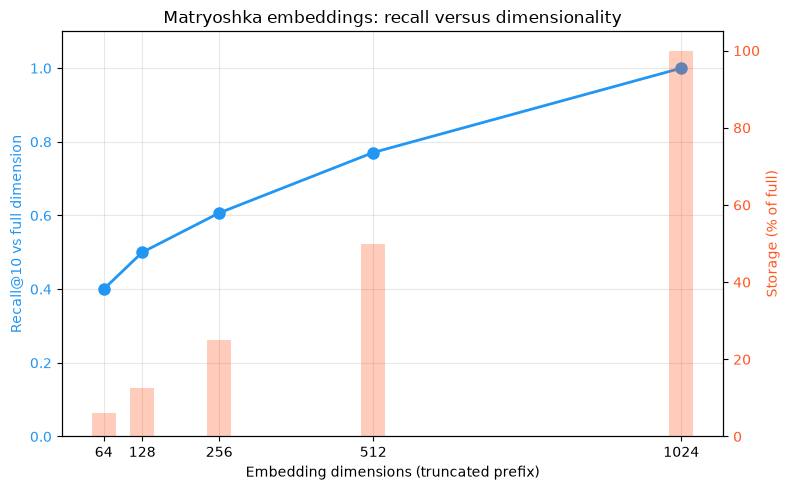

In [23]:
dims = sorted((int(d) for d in per_dim))
recalls = [per_dim[str(d)]["mean_recall_at_10_vs_full"] for d in dims]
storage_pct = [per_dim[str(d)]["storage_pct_of_full"] for d in dims]

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(dims, recalls, "o-", color="#2196F3", linewidth=2, markersize=8, label="Recall@10")
ax1.set_xlabel("Embedding dimensions (truncated prefix)")
ax1.set_ylabel("Recall@10 vs full dimension", color="#2196F3")
ax1.tick_params(axis="y", labelcolor="#2196F3")
ax1.set_ylim(0, 1.1)
ax1.set_xticks(dims)

ax2 = ax1.twinx()
ax2.bar(dims, storage_pct, width=40, alpha=0.3, color="#FF5722", label="Storage %")
ax2.set_ylabel("Storage (% of full)", color="#FF5722")
ax2.tick_params(axis="y", labelcolor="#FF5722")

ax1.set_title("Matryoshka embeddings: recall versus dimensionality")
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Recall degrades as we truncate, but storage falls in direct proportion to the dimension.
At 256 dimensions we keep only a quarter of the storage, but the truncated top-10 keeps
only about 60 percent of the full-dimension top-10. That is exactly why Pipeline E does
not serve the truncated vectors as final results: a 256d ranking alone would lose roughly
40 percent of the full-precision top-10. The truncated stage only has to keep the right
candidates **in the pool** of survivors, not rank them perfectly; the full-dimension
rerank then restores the precise ordering. Truncation is one way to build the cheap
stage; quantization (int8 for a 4x storage cut, binary for 32x) is the other, and both
plug into the same multi-stage pattern.

## Discussion: where the Pipelines Disagree

The averages hide the interesting behaviour. The table below shows, for five conditions,
the rank at which each query's first relevant movie appears (a dash means it did not
appear in the top 10). This is where the pipelines reveal their different characters.

In [24]:
def first_relevant_rank(ranked_ids, rel):
    for i, d in enumerate(ranked_ids, start=1):
        if d in rel:
            return i
    return None

show_conditions = ["A-bm25", "C-dense-small", "C-dense-large",
                   "D-hybrid-large", "E-matryoshka-large"]
rows = []
for q in queries:
    qid = q["id"]
    row = [qid, q["probe"][:18]]
    for name in show_conditions:
        r = first_relevant_rank(results[name][qid], relevant[qid])
        row.append(str(r) if r else "-")
    rows.append(row)
display_md("**Rank of the first relevant movie per query (lower is better, dash = not in top 10):**")
print_table(rows, headers=["Query", "Probe", "A BM25", "C small", "C large", "D large", "E large"])

**Rank of the first relevant movie per query (lower is better, dash = not in top 10):**

| Query   | Probe              | A BM25   | C small   | C large   | D large   | E large   |
|:--------|:-------------------|:---------|:----------|:----------|:----------|:----------|
| q01     | exact-title        | 1        | 1         | 1         | 1         | 1         |
| q02     | exact-title        | 1        | 1         | 1         | 1         | 1         |
| q03     | exact-title-ambigu | 2        | 1         | -         | 3         | -         |
| q04     | exact-cast-name    | 1        | 2         | 1         | 1         | 1         |
| q05     | cast-name-nl       | 1        | 2         | 1         | 1         | 1         |
| q06     | mixed-cast-plot    | 1        | 1         | 1         | 1         | 1         |
| q07     | genre-plot-semanti | 10       | 2         | 1         | 2         | 1         |
| q08     | genre-plot-semanti | 1        | 2         | 2         | 1         | 2         |
| q09     | paraphrase-noshare | -        | 6         | 1         | 6         | 1         |
| q10     | paraphrase-noshare | -        | 1         | 1         | 1         | 1         |
| q11     | paraphrase-noshare | -        | -         | 7         | -         | 7         |
| q12     | paraphrase-noshare | -        | 5         | 1         | 2         | 1         |
| q13     | open-semantic      | 2        | 4         | 5         | 3         | 5         |
| q14     | paraphrase-plot    | 1        | 1         | 1         | 1         | 1         |

The named examples make the pattern concrete:

- **BM25 wins exact names (q04, Samuel L. Jackson).** The actor-name query is dominated
  by BM25: it matches the name tokens directly and fills the top ranks with his films,
  while dense retrieval scatters because a proper noun carries little semantic signal.
  This is why hybrid pipelines keep BM25 in the mix.
- **The large dense model wins paraphrases (q09 Se7en, q12 Braveheart).** On plot
  paraphrases written to share no vocabulary with the overview, BM25 returns noise and
  the small model often misses, but the large model recovers the target from meaning
  alone. This is the recall that classical retrieval cannot reach.
- **Model capacity matters (q07, Toy Story).** For "animated film about toys that come
  to life", the small model's top result is A Goofy Movie (an animated film, wrong plot),
  while the large model returns Toy Story. The larger model resolves the finer semantic
  distinction.
- **Some queries are hard for everyone (q11, Leaving Las Vegas).** The paraphrase "a
  self-destructive man bent on ending his life bonds with a sex worker during his final
  days" shares no words with the overview and names no city. Even the large dense model
  only reaches the target around rank 7, and BM25 never finds it. Hard semantic queries
  remain hard.

### The small-versus-large tradeoff

The headline table also answers a question every deployment faces: is the big embedding
model worth its cost? The large Qwen model is far more expensive than the small MiniLM
one on both axes the benchmark measures. Per query it costs roughly 25 times more
(an order of magnitude slower, because the large model pushes the query through a much
bigger network), and it needs about 2.6 times the storage (2.05 MB against 0.77 MB for
the corpus matrix). The intuition is that paying all that should buy a large
quality gain. The numbers say otherwise: the gain is real but uneven, and most of it can
be bought far more cheaply.

The key comparison is in the hybrid rows. D-hybrid-small reaches MRR 0.693 and
D-hybrid-large reaches 0.702: the small hybrid model nearly matches the large one at a
fraction of the cost. Compare that to dense retrieval alone, where C-small (0.615) clearly
trails C-large (0.774): on its own, the small model leaves a real gap. Adding BM25 to the
small dense model is what closes almost all of that gap, because BM25 supplies the exact
matches the small model misses and lifts the fused ranking back up to within a whisker of
the large model. The expensive upgrade (a bigger model) and the cheap upgrade (a small
model plus BM25) land in nearly the same place.

<div style="border-left: 4px solid #2563EB; background: rgba(37, 99, 235, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#2563EB; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">A bigger model is not automatically worth its cost</strong><br>
The large model costs about 25 times more per query and about 2.6 times the storage, yet D-hybrid-small (MRR 0.693) nearly matches D-hybrid-large (0.702). Hybridisation recovers almost all of the large model's advantage cheaply: C-small alone (0.615) trails C-large (0.774), but adding BM25 closes most of that gap. The practical lesson is to reach for a small dense model plus BM25 first and measure the result, rather than assuming the larger model earns its cost. Here, it mostly does not.
</div>

<div style="border-left: 4px solid #C8102E; background: rgba(200, 16, 46, 0.06); padding: 0.6em 0.9em; margin: 0.6em 0; border-radius: 4px;">
<strong style="color:#C8102E; text-transform:uppercase; font-size:0.78em; letter-spacing:0.06em;">Match the pipeline to the collection and the use case</strong><br>
The book's practical recommendations fall straight out of this table. For small collections (under 10k documents), Pipeline C with a cross-encoder is enough. For the middle range (10k to 1M), Pipeline D (hybrid plus a reranker) is the robust default: it keeps BM25's exact-match strength and dense retrieval's paraphrase recall, and needs no weight tuning. Prefer a small embedding model plus BM25 over a larger model on its own: the benchmark shows the small hybrid nearly matches the large hybrid at a fraction of the cost, so measure the gain before paying for a bigger model. Reach for a larger model, a cross-encoder, or Pipeline E's multi-stage retrieval only when the collection size or the quality target demands it, and only after measurement justifies the cost. For exact-match-heavy use cases (product IDs, error codes, actor names), hybrid is mandatory because dense retrieval alone fails on proper nouns.
</div>

A closing word, back to Chapter 2. The disagreements above are not just pipeline
behaviour; some of them are judgment behaviour. Whether Virtuosity counts as "a detective
hunting a serial killer", or whether a CIA drug-cartel thriller counts as a "spy thriller
with a villain plotting global sabotage", are calls our judge made and another judge
might reverse. The incomplete pool means a pipeline that found a genuinely relevant movie
nobody else retrieved was penalised for it, scored as a miss. And 14 queries is a tiny
sample. These numbers earn their keep as a comparative lens on how the pipelines differ,
which is what this notebook set out to show; they are not a leaderboard, and Chapter 2
explains precisely why.

## Try It Yourself

In [25]:
# 1. Run your own query through all five pipelines and compare the top result.
my_query = "a hacker breaks into a corporate computer system"
for name in ["A-bm25", "C-dense-small", "C-dense-large", "D-hybrid-large", "E-matryoshka-large"]:
    ranked = conditions[name](my_query)
    top = id_to_title.get(ranked[0][0], "-") if ranked else "-"
    display_md(f"- **{name}**: {top}")

- **A-bm25**: Hackers

- **C-dense-small**: Hackers

- **C-dense-large**: Hackers

- **D-hybrid-large**: Hackers

- **E-matryoshka-large**: Hackers

In [26]:
# 2. Change the Matryoshka first-stage dimension and watch Pipeline E's result shift.
# A smaller first_dim is cheaper but keeps fewer of the right candidates in the pool.
for d in [64, 128, 256, 512]:
    ranked = multistage_matryoshka(q12_text, first_dim=d, top_k=3)
    titles = ", ".join(id_to_title.get(i, "-") for i, _ in ranked)
    display_md(f"- **first_dim={d}**: {titles}")

- **first_dim=64**: Braveheart, Target, Queen Margot

- **first_dim=128**: Braveheart, Target, Queen Margot

- **first_dim=256**: Braveheart, Target, Queen Margot

- **first_dim=512**: Braveheart, Target, Queen Margot